### Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)

### Carga del dataset

In [16]:
# Intentar importar google.colab para detectar si estamos en Colab
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # En Colab: pedimos que suban el archivo manualmente
    print("Ejecutando en Google Colab. Por favor, sube el archivo 'teen_phone_addiction.csv'")
    uploaded = files.upload()
    # El archivo se guarda en el directorio actual
    dataset_path = 'teen_phone_addiction.csv'
else:
    # En local: asumimos que el notebook está en 'notebooks/' y el dataset en '../dataset/'
    # Si no se encuentra, intentamos otras rutas comunes
    possible_paths = [
        os.path.join('..', 'dataset', 'teen_phone_addiction.csv'),
        os.path.join('dataset', 'teen_phone_addiction.csv'),   # por si acaso
        'teen_phone_addiction.csv'                            # si está en la misma carpeta
    ]
    dataset_path = None
    for path in possible_paths:
        if os.path.exists(path):
            dataset_path = path
            break

if dataset_path is None or not os.path.exists(dataset_path):
    raise FileNotFoundError(
        "No se encontró 'teen_phone_addiction.csv'. En local se espera en '../dataset/'. "
        "En Colab, súbelo cuando se solicite."
    )

df = pd.read_csv(dataset_path)
print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Ruta utilizada: {dataset_path}")
df.head(3)

Ejecutando en Google Colab. Por favor, sube el archivo 'teen_phone_addiction.csv'


Saving teen_phone_addiction.csv to teen_phone_addiction (1).csv
Dataset cargado: 3000 filas x 25 columnas
Ruta utilizada: teen_phone_addiction.csv


,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2


### Limpieza y separación de variables

In [3]:
# Eliminar columnas irrelevantes (ID, Name, Location)
columns_to_drop = ['ID', 'Name', 'Location']
df = df.drop(columns=[c for c in columns_to_drop if c in df.columns])

# Variable objetivo
target_col = 'Addiction_Level'
X_raw = df.drop(columns=[target_col])
y_raw = df[target_col]

# Identificar tipos de columnas
categorical_cols = X_raw.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_raw.select_dtypes(exclude=['object']).columns.tolist()

# Detectar columnas binarias (0/1) – aunque no se usan en el modelo, nos sirven para entender los datos
binary_cols = [col for col in numeric_cols if set(pd.unique(df[col].dropna())).issubset({0, 1})]

print(f"Variables predictoras: {len(X_raw.columns)}")
print(f"Categóricas: {categorical_cols}")
print(f"Numéricas: {numeric_cols}")
print(f"Binarias detectadas: {binary_cols}")
print(f"Rango de la variable objetivo: {y_raw.min()} - {y_raw.max()}")

Variables predictoras: 21
Categóricas: ['Gender', 'School_Grade', 'Phone_Usage_Purpose']
Numéricas: ['Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Family_Communication', 'Weekend_Usage_Hours']
Binarias detectadas: ['Parental_Control']
Rango de la variable objetivo: 1.0 - 10.0


### Preprocesamiento (One‑Hot Encoding y Escalado)

In [4]:
# Preprocesador: las numéricas se dejan pasar, las categóricas se codifican con OneHot (drop='first')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

# Aplicar preprocesador
X_processed = preprocessor.fit_transform(X_raw)
if hasattr(X_processed, 'toarray'):
    X_processed = X_processed.toarray()

# Escalado estándar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed)

print(f"Dimensiones después del preprocesamiento: {X_scaled.shape}")

Dimensiones después del preprocesamiento: (3000, 29)


### División en entrenamiento y prueba

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_raw, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")

Entrenamiento: 2400 muestras
Prueba: 600 muestras


### Entrenamiento del modelo (MLPRegressor)

In [6]:
modelo = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=500,
    random_state=42,
    verbose=True      # Activamos para ver el progreso
)

print("Entrenando la Red Neuronal...")
modelo.fit(X_train, y_train)
print("Entrenamiento completado.")

Entrenando la Red Neuronal...
Iteration 1, loss = 30.98561878
Iteration 2, loss = 19.52802531
Iteration 3, loss = 9.02476335
Iteration 4, loss = 2.70595911
Iteration 5, loss = 1.44851492
Iteration 6, loss = 1.16981723
Iteration 7, loss = 0.90078152
Iteration 8, loss = 0.84251266
Iteration 9, loss = 0.80017841
Iteration 10, loss = 0.76875049
Iteration 11, loss = 0.74248167
Iteration 12, loss = 0.71811036
Iteration 13, loss = 0.69479694
Iteration 14, loss = 0.67277411
Iteration 15, loss = 0.65247973
Iteration 16, loss = 0.63352124
Iteration 17, loss = 0.61482112
Iteration 18, loss = 0.59812363
Iteration 19, loss = 0.58189618
Iteration 20, loss = 0.56645805
Iteration 21, loss = 0.55118314
Iteration 22, loss = 0.53786075
Iteration 23, loss = 0.52403755
Iteration 24, loss = 0.51159201
Iteration 25, loss = 0.49829380
Iteration 26, loss = 0.48652145
Iteration 27, loss = 0.47405946
Iteration 28, loss = 0.46220483
Iteration 29, loss = 0.44777177
Iteration 30, loss = 0.43578945
Iteration 31, los

### Celda 7: Evaluación de la regresión (predicción continua)


In [15]:
y_pred_continuo = modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_continuo)
r2 = r2_score(y_test, y_pred_continuo)

print(f"Resultados de regresión (variable continua 0-10):")
print(f"  MAE (Error Absoluto Medio): {mae:.3f}")
print(f"  R² (Coeficiente de determinación): {r2:.3f}")

Resultados de regresión (variable continua 0-10):
  MAE (Error Absoluto Medio): 0.189
  R² (Coeficiente de determinación): 0.976


### Conversión a clasificación binaria (Adicto / No Adicto)


In [8]:
# Definimos el umbral: ≥ 6 se considera "Adicto" (Moderado+ según el original)
threshold = 6.0

y_test_bin = (y_test >= threshold).astype(int)
y_pred_bin = (y_pred_continuo >= threshold).astype(int)

# Etiquetas para los gráficos
clases = ['No Adicto', 'Adicto']

### Matriz de confusión y métricas de clasificación

In [9]:
cm = confusion_matrix(y_test_bin, y_pred_bin)
acc = accuracy_score(y_test_bin, y_pred_bin)
prec = precision_score(y_test_bin, y_pred_bin)
rec = recall_score(y_test_bin, y_pred_bin)
f1 = f1_score(y_test_bin, y_pred_bin)
roc_auc = roc_auc_score(y_test_bin, y_pred_continuo)  # Usamos la salida continua para AUC

print("="*50)
print("MÉTRICAS DE CLASIFICACIÓN (Umbral = {:.1f})".format(threshold))
print("="*50)
print(f"Exactitud (Accuracy):        {acc:.3f}")
print(f"Precisión (Precision):       {prec:.3f}")
print(f"Sensibilidad (Recall):       {rec:.3f}")
print(f"F1-Score:                    {f1:.3f}")
print(f"AUC-ROC:                     {roc_auc:.3f}")
print("\nReporte de clasificación:")
print(classification_report(y_test_bin, y_pred_bin, target_names=clases))

MÉTRICAS DE CLASIFICACIÓN (Umbral = 6.0)
Exactitud (Accuracy):        0.983
Precisión (Precision):       0.993
Sensibilidad (Recall):       0.989
F1-Score:                    0.991
AUC-ROC:                     0.998

Reporte de clasificación:
              precision    recall  f1-score   support

   No Adicto       0.85      0.90      0.88        39
      Adicto       0.99      0.99      0.99       561

    accuracy                           0.98       600
   macro avg       0.92      0.94      0.93       600
weighted avg       0.98      0.98      0.98       600



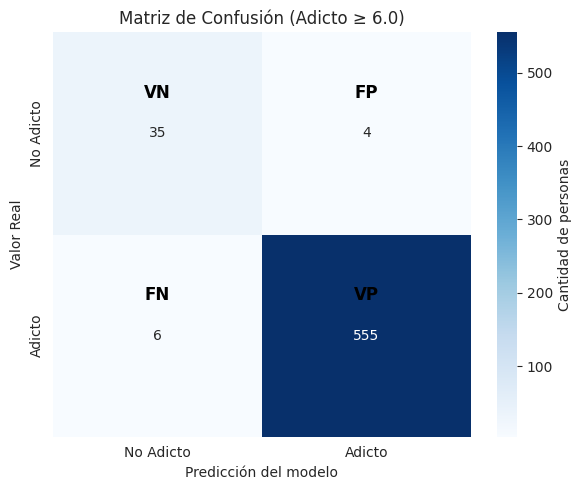

In [13]:
plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=clases, yticklabels=clases,
                 cbar_kws={'label': 'Cantidad de personas'})

# Añadir texto explicativo a cada cuadrante
ax.text(0.5, 0.3, 'VN', ha='center', va='center', fontsize=12, color='black', weight='bold')
ax.text(1.5, 0.3, 'FP', ha='center', va='center', fontsize=12, color='black', weight='bold')
ax.text(0.5, 1.3, 'FN', ha='center', va='center', fontsize=12, color='black', weight='bold')
ax.text(1.5, 1.3, 'VP', ha='center', va='center', fontsize=12, color='black', weight='bold')

plt.title(f'Matriz de Confusión (Adicto ≥ {threshold})')
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

### Distribución de los valores reales vs predichos

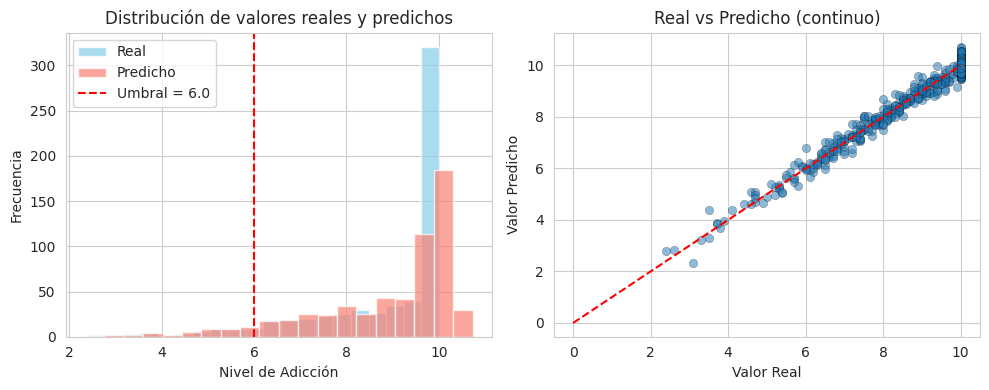

In [17]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(y_test, bins=20, alpha=0.7, label='Real', color='skyblue')
plt.hist(y_pred_continuo, bins=20, alpha=0.7, label='Predicho', color='salmon')
plt.axvline(threshold, color='red', linestyle='--', label=f'Umbral = {threshold}')
plt.xlabel('Nivel de Adicción')
plt.ylabel('Frecuencia')
plt.title('Distribución de valores reales y predichos')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_continuo, alpha=0.5, edgecolors='k', linewidth=0.3)
plt.plot([0, 10], [0, 10], 'r--')
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Real vs Predicho (continuo)')
plt.tight_layout()
plt.show()

### Análisis de umbrales – cómo cambian las métricas con el umbral

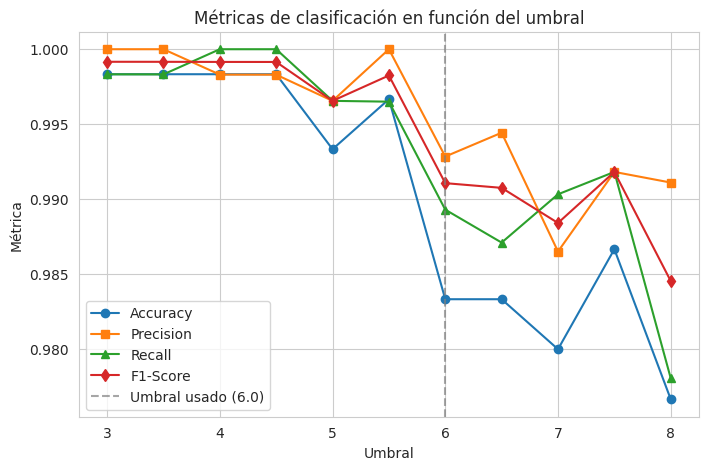

In [12]:
# Puedes experimentar variando el valor de threshold
umbrales = np.arange(3.0, 8.5, 0.5)
accs, precs, recs, f1s = [], [], [], []

for t in umbrales:
    y_t = (y_test >= t).astype(int)
    y_p = (y_pred_continuo >= t).astype(int)
    accs.append(accuracy_score(y_t, y_p))
    precs.append(precision_score(y_t, y_p, zero_division=0))
    recs.append(recall_score(y_t, y_p, zero_division=0))
    f1s.append(f1_score(y_t, y_p, zero_division=0))

plt.figure(figsize=(8, 5))
plt.plot(umbrales, accs, marker='o', label='Accuracy')
plt.plot(umbrales, precs, marker='s', label='Precision')
plt.plot(umbrales, recs, marker='^', label='Recall')
plt.plot(umbrales, f1s, marker='d', label='F1-Score')
plt.axvline(threshold, color='gray', linestyle='--', alpha=0.7, label=f'Umbral usado ({threshold})')
plt.xlabel('Umbral')
plt.ylabel('Métrica')
plt.title('Métricas de clasificación en función del umbral')
plt.legend()
plt.grid(True)
plt.show()